C:\Users\Lenovo\AppData\Local\Temp\ipykernel_143208\1883615911.py:95: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df0 = pd.read_csv(file)


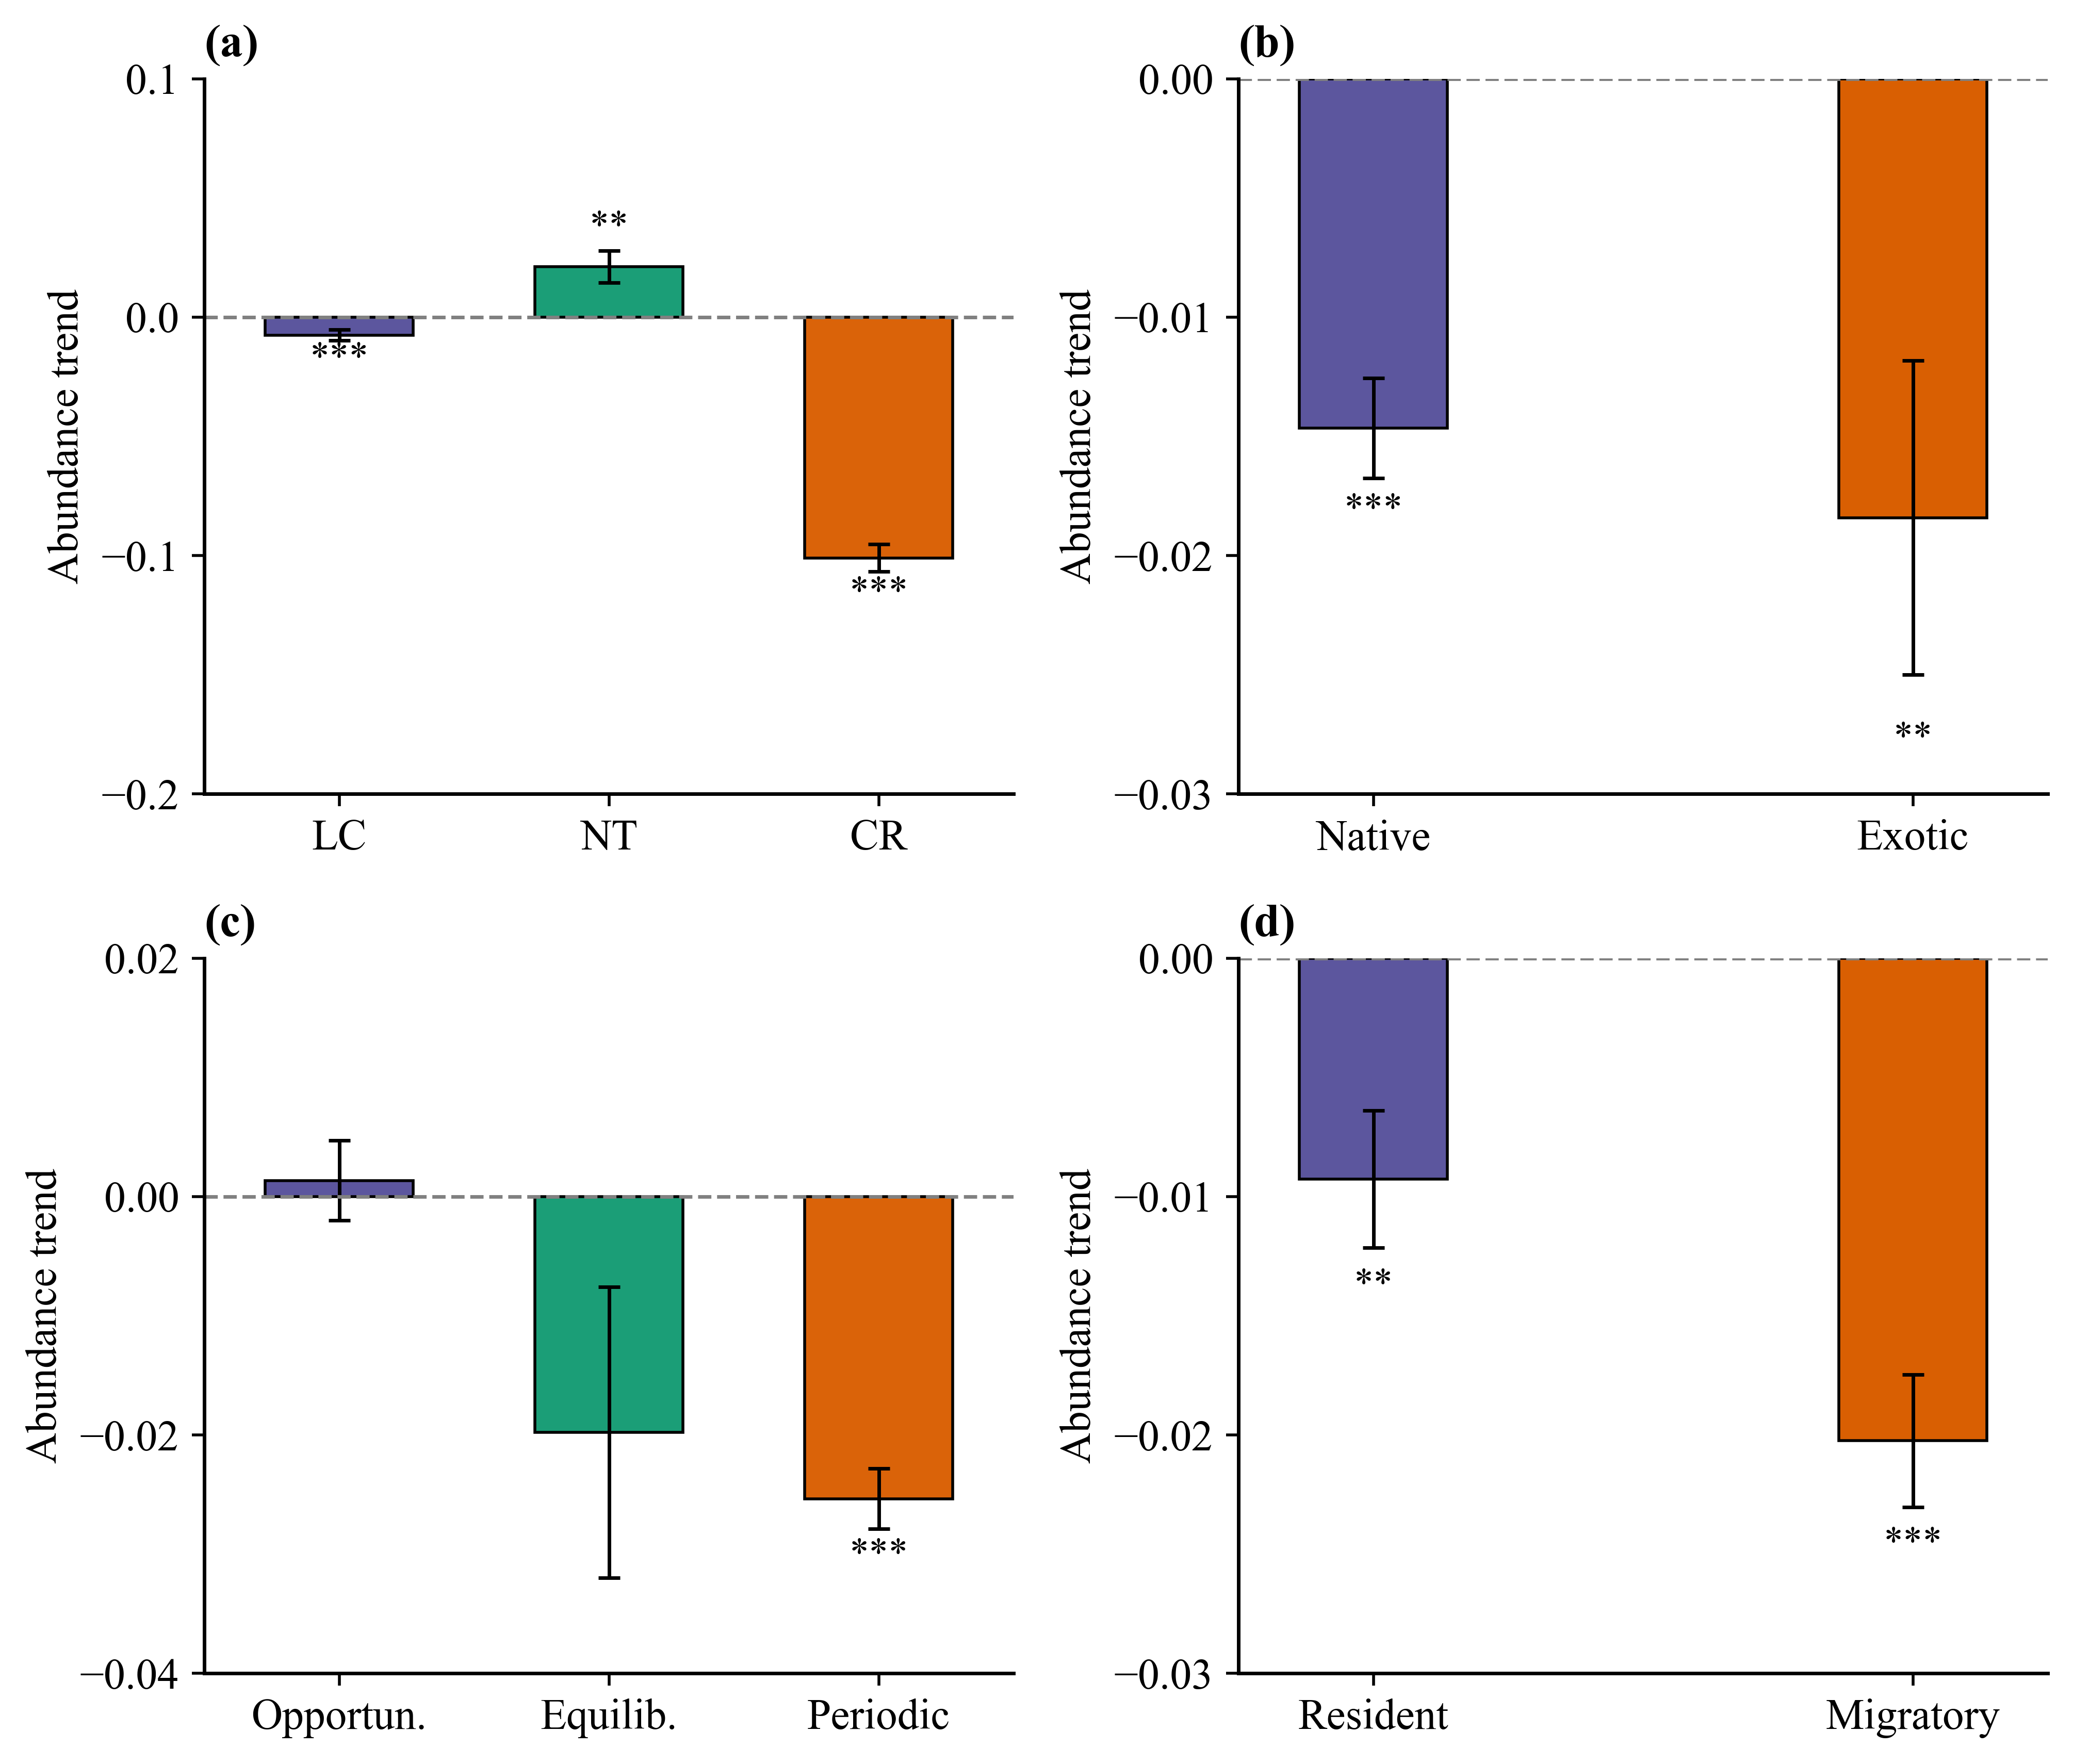

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.linewidth": 1,
    "mathtext.fontset": "stix",
})
BAR_WIDTH = 0.55

# =========================================================
# helpers
# =========================================================
def mean_se_p(sub):
    sub = pd.Series(sub).dropna()
    mean = sub.mean()
    se = sub.std(ddof=1) / np.sqrt(len(sub))
    _, p = ttest_1samp(sub, 0.0)
    return mean, se, p

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def draw_bar_panel(ax, labels, means, ses, ps, colors, ylabel, title,
                   ylim, yticks, panel_label, total_slots=3):
    
    if len(labels) == 3:
        x = np.array([0, 1, 2])
    elif len(labels) == 2:
        x = np.array([0, 2])
    else:
        x = np.arange(len(labels))

    for i in range(len(labels)):
        if pd.isna(means[i]):
            continue

        ax.bar(
            x[i],
            means[i],
            width=BAR_WIDTH,
            color=colors[i],
            edgecolor="black",
            linewidth=0.8
        )

        ax.errorbar(
            x[i],
            means[i],
            yerr=ses[i],
            fmt="none",
            ecolor="black",
            elinewidth=1,
            capsize=3
        )

        star = p_to_star(ps[i])
        if star != "":
            offset = ses[i] * 1.3 if np.isfinite(ses[i]) else 0.01
            y = means[i] + offset if means[i] >= 0 else means[i] - offset
            ax.text(
                x[i], y, star,
                ha="center",
                va="bottom" if means[i] >= 0 else "top",
                fontsize=11
            )

    ax.axhline(0, linestyle="--", color="gray", linewidth=1)
    ax.set_xlim(-0.5, total_slots - 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    ax.set_ylabel(ylabel)
    ax.set_title(panel_label, loc="left", fontsize=13, fontweight="bold")
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =========================================================
# read data
# =========================================================
file = r"D:\NC\Data\rivernet\inputdata\Abundance_slope_with_traits_clean.csv"
df0 = pd.read_csv(file)

# =========================================================
# figure
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(8.2, 7.0), dpi=500)
axes = axes.flatten()

# =========================================================
# (a) IUCN - All
# =========================================================
df = df0.copy()
cols = ["SiteID", "Species", "slope_abundance", "zone", "IUCN"]
df = df[cols].dropna()
IUCN_LEVELS = ["LC", "NT", "CR"]
df = df[df["IUCN"].isin(IUCN_LEVELS)]

labels = ["LC", "NT", "CR"]
bar_colors = ["#5c569e", "#1b9e77", "#da6309"]
means, ses, ps = [], [], []

for ic in IUCN_LEVELS:
    sub = df[df["IUCN"] == ic]["slope_abundance"]
    mean, se, p = mean_se_p(sub)
    means.append(mean)
    ses.append(se)
    ps.append(p)

draw_bar_panel(
    axes[0], labels, means, ses, ps, bar_colors,
    ylabel="Abundance trend",
    title="",
    ylim=(-0.2, 0.1),
    yticks=[-0.2, -0.1, 0.0, 0.1],
    panel_label="(a)"
)

# =========================================================
# (b) Native / Exotic - All
# =========================================================
df = df0.copy()
cols = ["SiteID", "Species", "slope_abundance", "slope_temp", "zone", "NativeStatus_final"]
df = df[cols].dropna()
df["NativeStatus_final"] = df["NativeStatus_final"].astype(str)

groups = ["native", "exotic"]
labels = ["Native", "Exotic"]
bar_colors = ["#5c569e", "#d95f02"]
means, ses, ps = [], [], []

for st in groups:
    sub = df[df["NativeStatus_final"] == st]["slope_abundance"]
    mean, se, p = mean_se_p(sub)
    means.append(mean)
    ses.append(se)
    ps.append(p)

draw_bar_panel(
    axes[1], labels, means, ses, ps, bar_colors,
    ylabel="Abundance trend",
    title="",
    ylim=(-0.03, 0.0),
    yticks=[-0.03, -0.02, -0.01,0.00],
    panel_label="(b)"
)

# =========================================================
# (c) Strategy - All
# =========================================================
df = df0.copy()
cols = ["SiteID", "Species", "slope_abundance", "slope_temp", "zone", "Strategy"]
df = df[cols].dropna()
df["Strategy"] = df["Strategy"].astype(str)

strategies = ["Opportunistic", "Equilibrium", "Periodic"]
min_species = 2
min_records = 10

labels = ["Opportun.", "Equilib.", "Periodic"]
bar_colors = ["#5c569e", "#1b9e77", "#da6309"]
means, ses, ps = [], [], []

for st in strategies:
    sub_all = df[df["Strategy"] == st]
    sub = sub_all["slope_abundance"]

    n_species = sub_all["Species"].nunique()
    n_records = len(sub_all)

    if n_species < min_species or n_records < min_records:
        means.append(np.nan)
        ses.append(np.nan)
        ps.append(np.nan)
    else:
        mean, se, p = mean_se_p(sub)
        means.append(mean)
        ses.append(se)
        ps.append(p)

draw_bar_panel(
    axes[2], labels, means, ses, ps, bar_colors,
    ylabel="Abundance trend",
    title="",
    ylim=(-0.04, 0.02),
    yticks=[-0.04, -0.02, 0.00,0.02],
    panel_label="(c)"
)

# =========================================================
# (d) Resident / Migratory - All
# =========================================================
df = df0.copy()
cols = ["SiteID", "Species", "slope_abundance", "slope_temp", "zone", "Migratory"]
df = df[cols].dropna()
df["Migratory"] = (
    df["Migratory"].astype(str).str.strip().str.upper().map({"TRUE": 1, "FALSE": 0})
)
df = df.dropna(subset=["Migratory"])
df["Migratory"] = df["Migratory"].astype(int)
df["Group"] = df["Migratory"].map({0: "Resident", 1: "Migratory"})

groups = ["Resident", "Migratory"]
labels = ["Resident", "Migratory"]
bar_colors = ["#5c569e", "#d95f02"]
means, ses, ps = [], [], []

for st in groups:
    sub = df[df["Group"] == st]["slope_abundance"]
    mean, se, p = mean_se_p(sub)
    means.append(mean)
    ses.append(se)
    ps.append(p)

draw_bar_panel(
    axes[3], labels, means, ses, ps, bar_colors,
    ylabel="Abundance trend",
    title="",
    ylim=(-0.03, 0),
    yticks=[ -0.03, -0.02, -0.01, 0.00],
    panel_label="(d)"
)

plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\extendFig13.png", dpi=600, bbox_inches="tight")
plt.show()